# Text Mining Workflow for Grimm Tales: Predicting ATU Topic

This notebook translates the Orange workflow into Python.

It is divided into two parts:

1. **Non-supervised learning**: explores the tales without using labels, using Bag-of-Words/TF-IDF, distance matrices, clustering, and 2D visualization.
2. **Supervised learning**: predicts `ATU Topic` using a stratified 70/30 train-test split and compares several classifiers.

The preprocessing follows the requested steps:

- lowercase text
- remove URLs
- apply regular expressions to keep words and clean lines
- remove stopwords



## Dataset explanation and example

This notebook uses `grimm-tales-selected.csv` to predict **`ATU Topic`**, the broad folklore category for each Grimm tale.

Each row represents one tale and includes:

| Column | Meaning | Used as model input? |
|---|---|---|
| `Title` | Tale title | Yes |
| `Abstract` | Short summary | Yes |
| `Content` | Full tale text | Yes |
| `ATU Topic` | Target label to predict | No, this is the answer |
| `ATU Numerical` | Folklore type number | No, possible label leakage |
| `ATU Type` | More specific ATU subtype | No, possible label leakage |

**Example row**

- **Title:** Brier Rose
- **ATU Topic:** `Tales of Magic`
- **Abstract:** An offended witch curses a young princess to die from pricking her finger on a spindle on her 15th birthday. A good witch blunts the curse by instead having her fall asleep for 100 years.

The task is a text-classification problem: given the title, abstract, and content of a tale, predict whether the tale belongs to an ATU topic such as **`Animal Tales`** or **`Tales of Magic`**.

The first two rows in the uploaded CSV look like schema/meta rows rather than real tales, so the notebook removes them before modeling.


In [1]:
# If needed, uncomment the next line in a fresh environment.
# %pip install pandas numpy matplotlib scikit-learn wordcloud scipy

from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

import functions as ftm

pd.set_option("display.max_colwidth", 160)
RANDOM_STATE = 42


In [2]:
# Load the dataset.
# The first path works in this notebook environment; the second works when the CSV is beside the notebook.
df = pd.read_csv("grimm-tales-selected.csv")
print("Raw shape:", df.shape)
display(df.head())


Raw shape: (44, 6)


,ATU Topic,Title,Abstract,Content,ATU Numerical,ATU Type
0,Tales of Magic,A Tale About the Boy Who Went Forth to Learn What Fear Was,A simple boy who just wants to be frightened.,"A certain father had two sons, the elder of who was smart and sensible, and could do everything, but the younger was stupid and could neither learn nor unde...",326.0,Supernatural Adversaries
1,Tales of Magic,Brier Rose,An offended witch curses a young princess to die from pricking her finger on a spindle on her 15th birthday. A good witch blunts the curse by instead having...,"A king and queen once upon a time reigned in a country a great way off, where there were in those days fairies. Now this king and queen had plenty of money,...",410.0,Supernatural or Enchanted Relatives
2,Animal Tales,Cat and Mouse in Partnership,"A mouse lives with a cat, and the cat eats all the fat.","A certain cat had made the acquaintance of a mouse, and had said so much to her about the great love and friendship she felt for her, that at length the mou...",15.0,Wild Animals
3,Tales of Magic,Cinderella,"The familiar story of a girl marrying a prince, despite her evil step-sisters doing their best to keep her down. This original version is a bit more bloody ...","The wife of a rich man fell sick; and when she felt that her end drew nigh, she called her only daughter to her bed-side, and said, ‘Always be a good girl, ...",510A,Supernatural Helpers
4,Tales of Magic,Hansel and Gretel,"A poor woodcutter can afford to feed his children, so he abandons them in the forest. They find an edible house, but the witch who lives inside ensnares the...",Hard by a great forest dwelt a poor wood-cutter with his wife and his two children. The boy was called Hansel and the girl Gretel. He had little to bite and...,327A,Supernatural Adversaries


In [3]:
# Normalize whitespace and protect against missing values.
text_columns = ["Title", "Abstract", "Content"]
for col in text_columns:
    df[col] = df[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

# Build the input document.
# We use Title + Abstract + Content as features.
# We do not use ATU Numerical or ATU Type because they are taxonomy labels and could leak the target.
df["raw_text"] = (
    df["Title"] + ". " +
    df["Abstract"] + ". " +
    df["Content"]
)

print("Clean shape:", df.shape)
print("\nTarget distribution:")
display(df["ATU Topic"].value_counts().to_frame("count"))

display(df[["Title", "ATU Topic", "Abstract"]].head())


Clean shape: (44, 7)

Target distribution:


,count
ATU Topic,
Tales of Magic,26
Animal Tales,18


,Title,ATU Topic,Abstract
0,A Tale About the Boy Who Went Forth to Learn What Fear Was,Tales of Magic,A simple boy who just wants to be frightened.
1,Brier Rose,Tales of Magic,An offended witch curses a young princess to die from pricking her finger on a spindle on her 15th birthday. A good witch blunts the curse by instead having...
2,Cat and Mouse in Partnership,Animal Tales,"A mouse lives with a cat, and the cat eats all the fat."
3,Cinderella,Tales of Magic,"The familiar story of a girl marrying a prince, despite her evil step-sisters doing their best to keep her down. This original version is a bit more bloody ..."
4,Hansel and Gretel,Tales of Magic,"A poor woodcutter can afford to feed his children, so he abandons them in the forest. They find an edible house, but the witch who lives inside ensnares the..."


## Preprocessing decisions

The workflow uses preprocessing before vectorization because raw fairy-tale text contains punctuation, capitalization differences, line breaks, and words that usually do not help classification.

The function below implements the requested preprocessing:

1. **Lowercase**: makes `Witch`, `witch`, and `WITCH` the same token.
2. **Remove URLs**: avoids treating web links as meaningful words.
3. **Regular expressions**: removes non-letter characters and normalizes repeated spaces and line breaks.
4. **Remove stopwords**: removes very common English words such as `the`, `and`, `of`.

This produces cleaner tokens for word clouds, Bag-of-Words, TF-IDF, clustering, and supervised classification.


```python
phrase = "Eu hj fui á praia e ecnontrei UM amigo e 1 colega de trabalho."

In [4]:
STOPWORDS = set(ENGLISH_STOP_WORDS)

def preprocess_text(text: str) -> str:
    """Lowercase, remove URLs, regex-clean lines, and remove stopwords."""
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)                 # keep letters/spaces only
    text = re.sub(r"\s+", " ", text).strip()              # normalize whitespace and lines
    tokens = [tok for tok in text.split() if tok not in STOPWORDS and len(tok) > 2]
    return " ".join(tokens)

df["processed_text"] = df["raw_text"].apply(preprocess_text)

display(df[["Title", "raw_text", "processed_text", "ATU Topic"]].head(3))


,Title,raw_text,processed_text,ATU Topic
0,A Tale About the Boy Who Went Forth to Learn What Fear Was,"A Tale About the Boy Who Went Forth to Learn What Fear Was. A simple boy who just wants to be frightened.. A certain father had two sons, the elder of who w...",tale boy went forth learn fear simple boy just wants frightened certain father sons elder smart sensible younger stupid learn understand people saw said fel...,Tales of Magic
1,Brier Rose,Brier Rose. An offended witch curses a young princess to die from pricking her finger on a spindle on her 15th birthday. A good witch blunts the curse by in...,brier rose offended witch curses young princess die pricking finger spindle birthday good witch blunts curse instead having fall asleep years king queen tim...,Tales of Magic
2,Cat and Mouse in Partnership,"Cat and Mouse in Partnership. A mouse lives with a cat, and the cat eats all the fat.. A certain cat had made the acquaintance of a mouse, and had said so m...",cat mouse partnership mouse lives cat cat eats fat certain cat acquaintance mouse said great love friendship felt length mouse agreed live house make provis...,Animal Tales


## Word clouds before and after preprocessing

The first word cloud uses the raw text. It often emphasizes common words and repeated function words.

The second word cloud uses the preprocessed text. It should emphasize more meaningful tale vocabulary such as characters, objects, actions, and motifs.


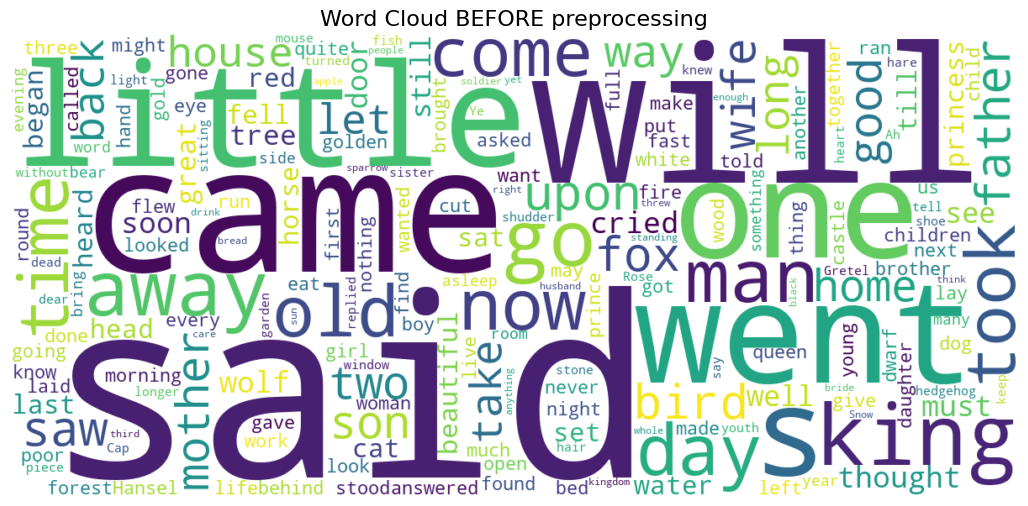

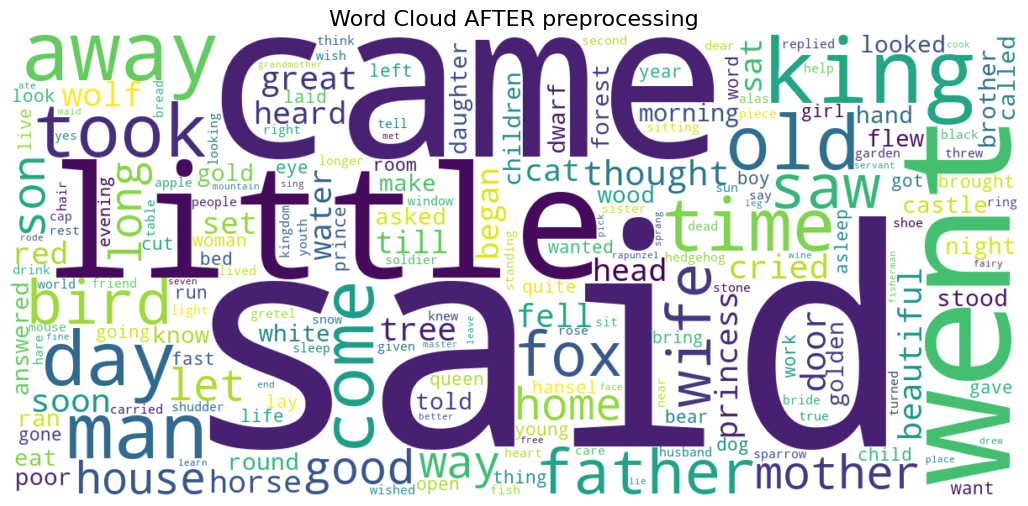

In [5]:
raw_corpus = " ".join(df["raw_text"].fillna("").astype(str))
processed_corpus = " ".join(df["processed_text"].fillna("").astype(str))

ftm.show_wordcloud(raw_corpus, "Word Cloud BEFORE preprocessing")
ftm.show_wordcloud(processed_corpus, "Word Cloud AFTER preprocessing")

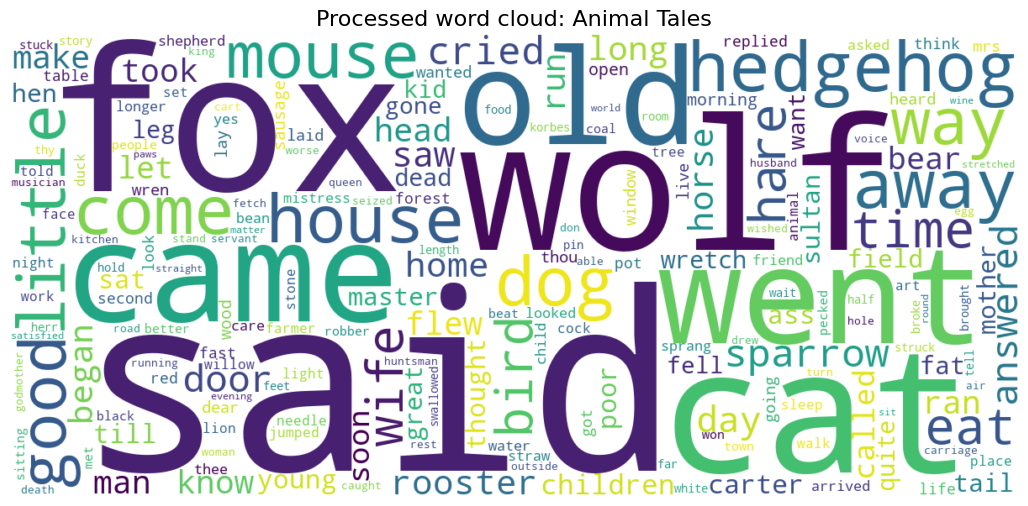

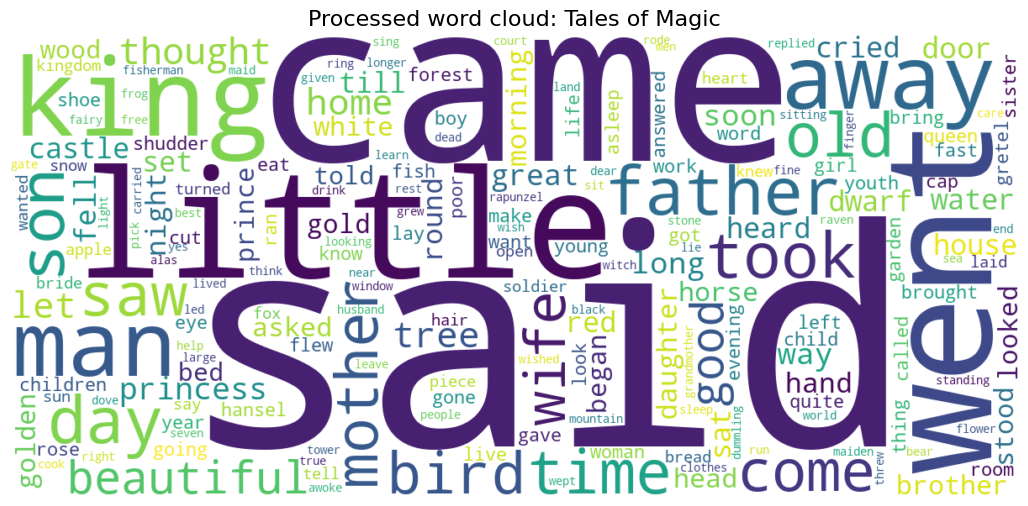

In [6]:
# Optional: word clouds by target class after preprocessing.
for topic in sorted(df["ATU Topic"].unique()):
    topic_text = " ".join(df.loc[df["ATU Topic"] == topic, "processed_text"])
    ftm.show_wordcloud(topic_text, f"Processed word cloud: {topic}")

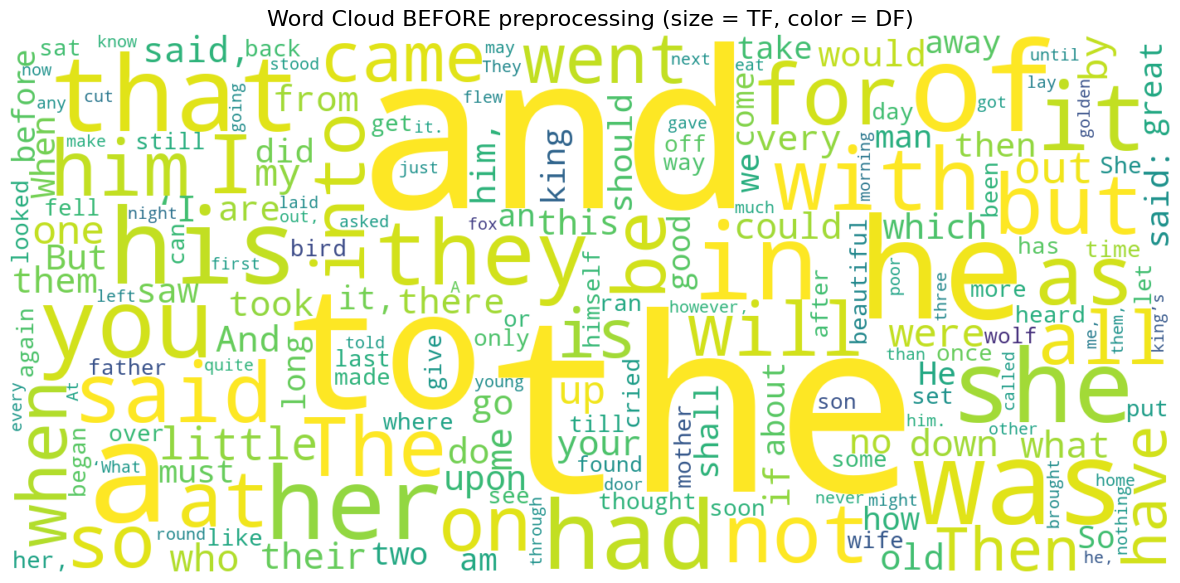

Word Cloud BEFORE preprocessing (size = TF, color = DF)
- Number of documents: 44
- Vocabulary size: 7942
- Word size encodes: term frequency (TF)
- Word color encodes: document frequency (DF)


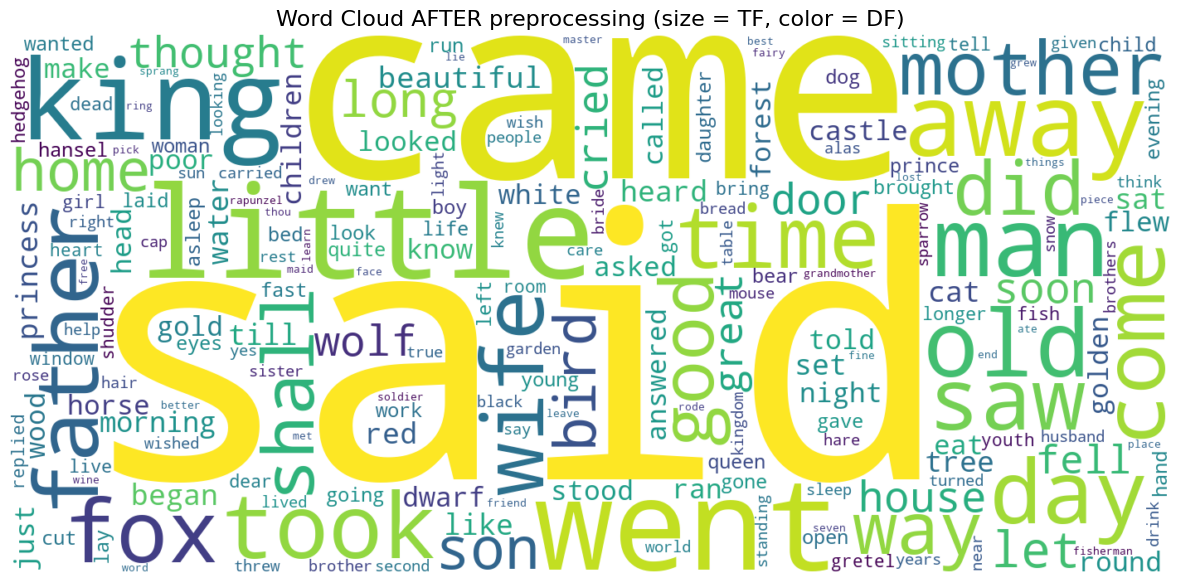

Word Cloud AFTER preprocessing (size = TF, color = DF)
- Number of documents: 44
- Vocabulary size: 3691
- Word size encodes: term frequency (TF)
- Word color encodes: document frequency (DF)


In [7]:
# BEFORE preprocessing
ftm.show_wordcloud_tf_size_df_color(
    df["raw_text"],
    "Word Cloud BEFORE preprocessing (size = TF, color = DF)"
)

# AFTER preprocessing
ftm.show_wordcloud_tf_size_df_color(
    df["processed_text"],
    "Word Cloud AFTER preprocessing (size = TF, color = DF)"
)

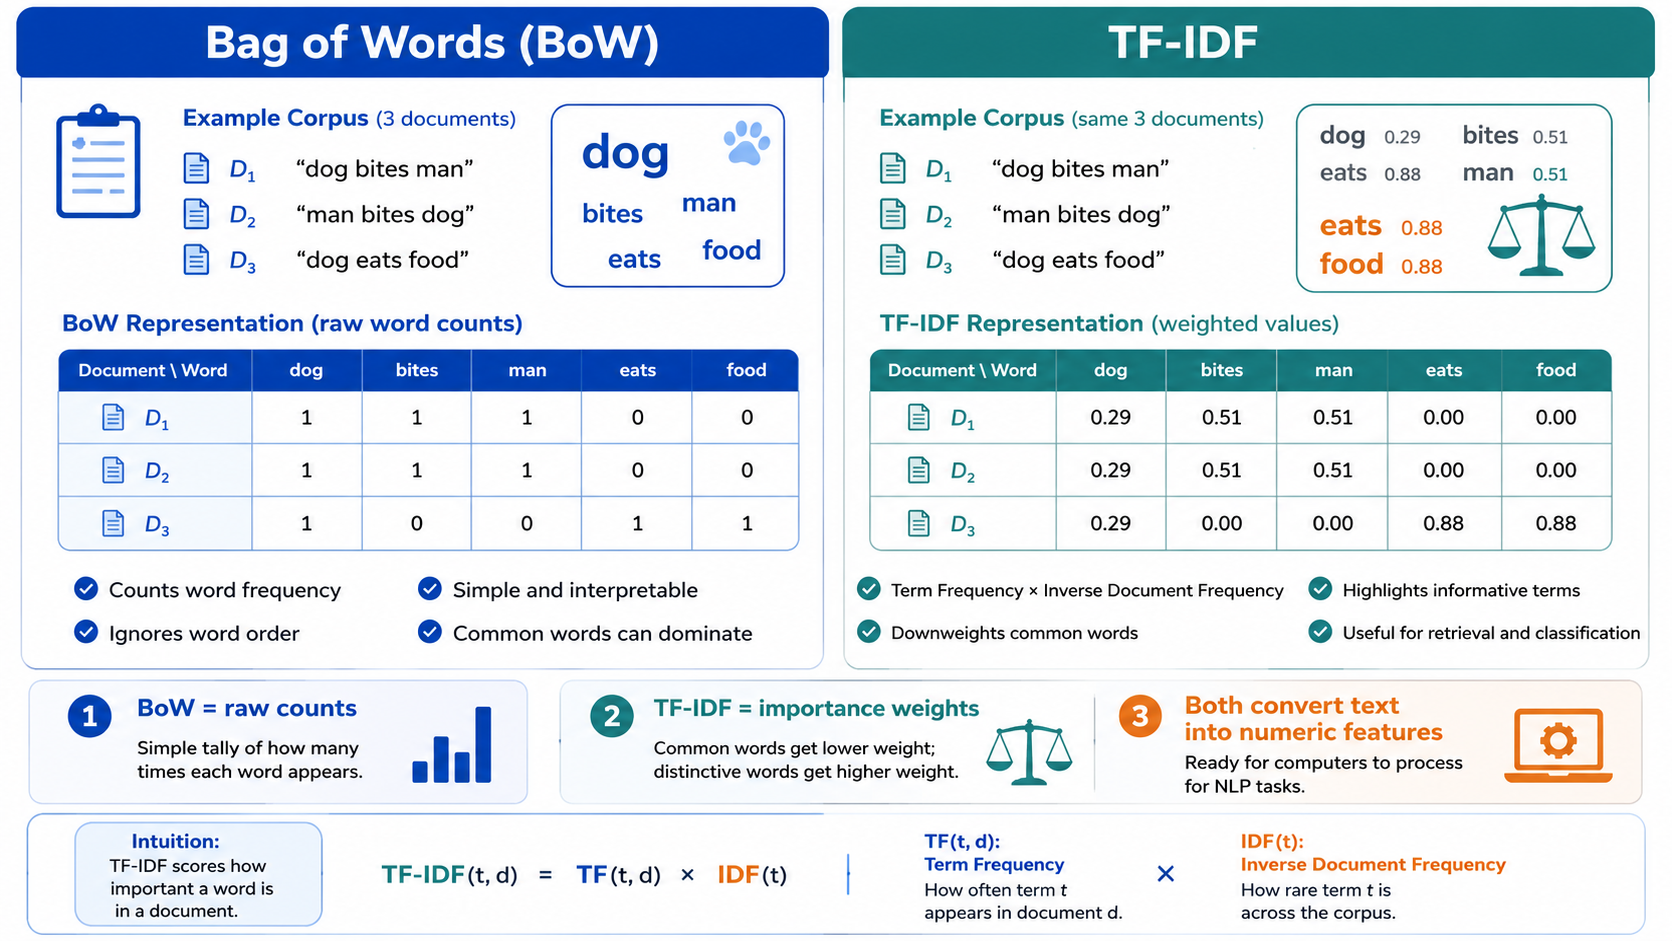

# Part 1 — Non-supervised learning

In this section the algorithm does **not** use `ATU Topic` to learn.  
The labels are used only afterward to interpret whether the unsupervised structure resembles the known ATU topics.

- Corpus → preprocessing
- Bag of Words / TF-IDF
- Distances
- Hierarchical clustering
- 2D visualization


In [8]:
# Bag-of-Words representation.
count_vectorizer = CountVectorizer(max_features=1000, min_df=1)
X_bow = count_vectorizer.fit_transform(df["processed_text"])

bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=count_vectorizer.get_feature_names_out(),
    index=df["Title"]
)

print("Bag-of-Words matrix shape:", bow_df.shape)
display(bow_df.iloc[:5, :15])


Bag-of-Words matrix shape: (44, 1000)


,able,account,advice,afraid,ago,agreed,air,alas,alighted,alive,allowed,aloud,anger,angry,animals
Title,,,,,,,,,,,,,,,
A Tale About the Boy Who Went Forth to Learn What Fear Was,1,0,0,1,1,0,1,0,0,1,1,0,0,1,0
Brier Rose,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
Cat and Mouse in Partnership,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0
Cinderella,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Hansel and Gretel,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1


In [9]:
import importlib
importlib.reload(ftm)  # Reload the functions module to pick up any changes.
scatter_df, label_examples = ftm.plot_feature_selection_scatter(
    df=df,
    text_column="raw_text",
    vectorizer=count_vectorizer,
    stopwords=STOPWORDS,
    max_points=8000,
    jitter=1.8,
    random_state=RANDOM_STATE,
    title="Grimm corpus: stopwords removidas vs features selecionadas"
)

display(label_examples[["word", "frequency", "category"]])

,word,frequency,category
0,the,4465,Stopword removida
44,down,207,Stopword removida
113,can,87,Stopword removida
216,find,42,Stopword removida
461,because,17,Stopword removida
825,thereupon,8,Stopword removida
1695,wherever,3,Stopword removida
3851,ho,1,Stopword removida
12,said,668,Dentro das features selecionadas
244,tell,36,Dentro das features selecionadas


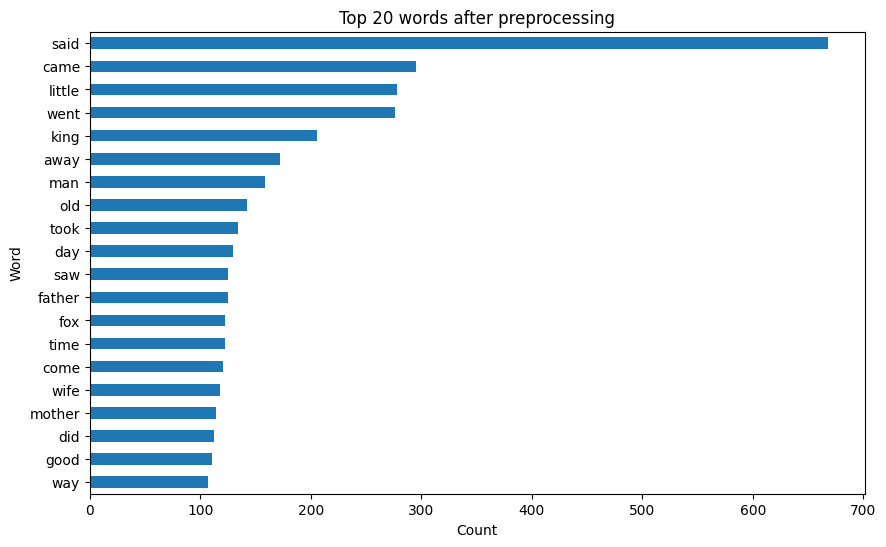

In [10]:
# Top words overall after preprocessing.
word_counts = pd.Series(np.asarray(X_bow.sum(axis=0)).ravel(), index=count_vectorizer.get_feature_names_out())
top_words = word_counts.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_words.sort_values().plot(kind="barh")
plt.title("Top 20 words after preprocessing")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()


In [11]:
# TF-IDF representation for distances and clustering.
tfidf_vectorizer = TfidfVectorizer(max_features=500, min_df=3, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

# Cosine distances are commonly used for text because document length can vary a lot.
distance_matrix = cosine_distances(X_tfidf)
print("Distance matrix shape:", distance_matrix.shape)
display(pd.DataFrame(distance_matrix, index=df["Title"], columns=df["Title"]).iloc[:5, :5])


Distance matrix shape: (44, 44)


Title,A Tale About the Boy Who Went Forth to Learn What Fear Was,Brier Rose,Cat and Mouse in Partnership,Cinderella,Hansel and Gretel
Title,,,,,
A Tale About the Boy Who Went Forth to Learn What Fear Was,0.000000,0.691933,0.859164,0.723327,0.655851
Brier Rose,0.691933,0.000000,0.911907,0.674080,0.718289
Cat and Mouse in Partnership,0.859164,0.911907,0.000000,0.888272,0.805883
Cinderella,0.723327,0.674080,0.888272,0.000000,0.720779
Hansel and Gretel,0.655851,0.718289,0.805883,0.720779,0.000000


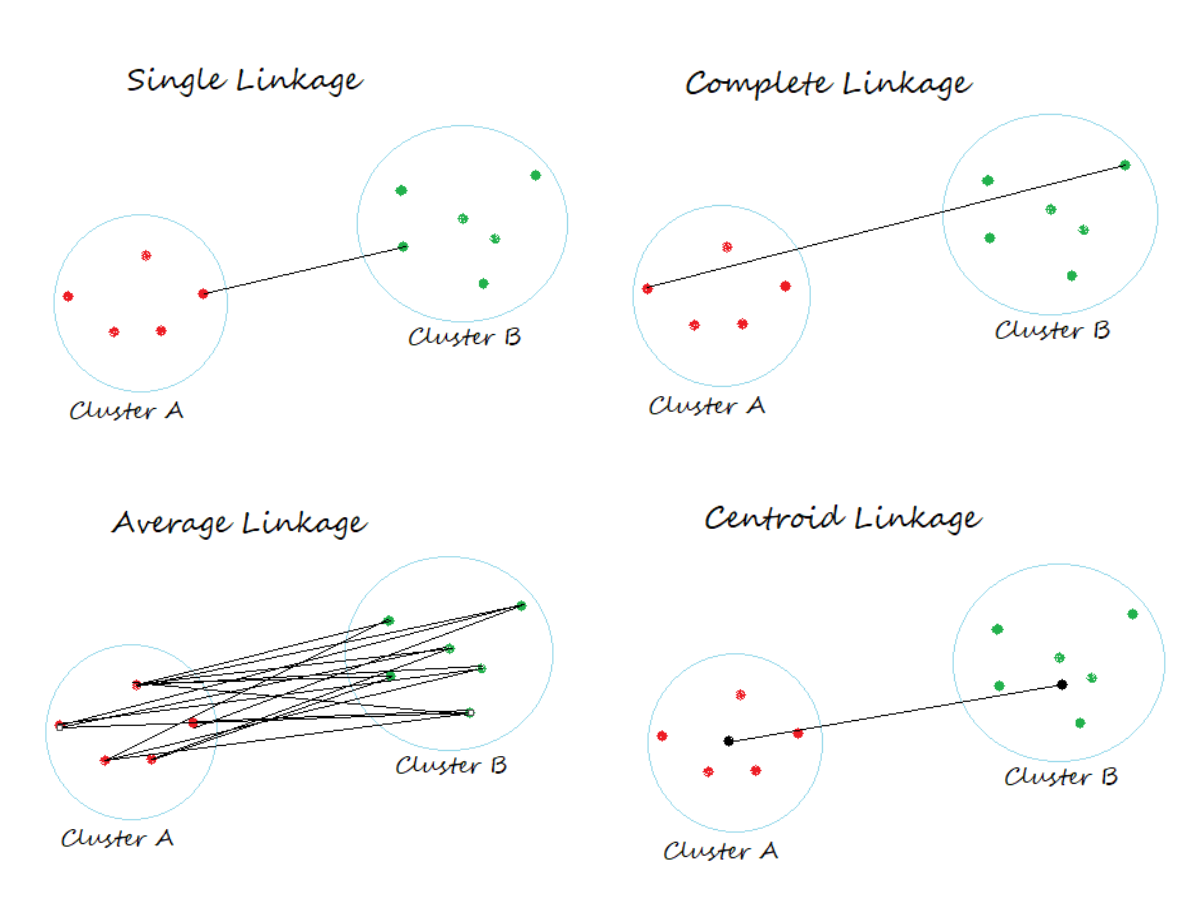

In [12]:
# Hierarchical clustering.
# There are 2 known ATU Topic classes in this cleaned dataset, so we ask for 2 clusters.
n_topics = df["ATU Topic"].nunique()

clusterer = AgglomerativeClustering(
    n_clusters=n_topics,
    linkage="ward"
)
clusters = clusterer.fit_predict(distance_matrix)

df["cluster"] = clusters

print("Cluster vs. true ATU Topic:")
display(pd.crosstab(df["cluster"], df["ATU Topic"]))


Cluster vs. true ATU Topic:


ATU Topic,Animal Tales,Tales of Magic
cluster,,
0,12,26
1,6,0


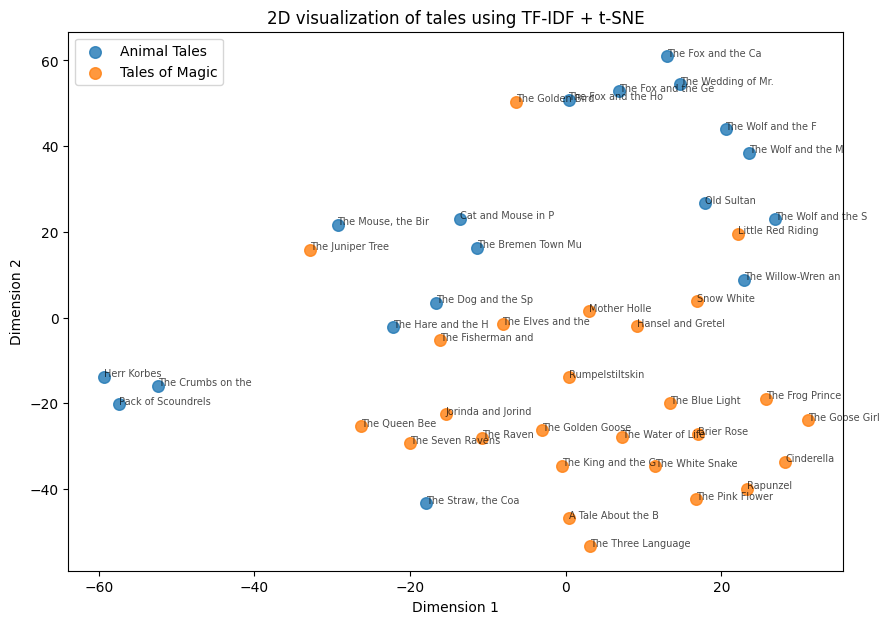

In [13]:
# 2D visualization of the tales.
# TruncatedSVD reduces sparse TF-IDF to a smaller numeric representation.
# t-SNE then maps the tales to 2D for visualization.

svd_components = min(10, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
X_svd = TruncatedSVD(n_components=svd_components, random_state=RANDOM_STATE).fit_transform(X_tfidf)

perplexity = min(10, max(2, (len(df) - 1) // 3))
X_2d = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="random",
    learning_rate="auto",
    random_state=RANDOM_STATE
).fit_transform(X_svd)

plot_df = pd.DataFrame({
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "ATU Topic": df["ATU Topic"].values,
    "cluster": df["cluster"].values,
    "Title": df["Title"].values
})

plt.figure(figsize=(10, 7))
for topic, group in plot_df.groupby("ATU Topic"):
    plt.scatter(group["x"], group["y"], label=topic, s=70, alpha=0.8)

for _, row in plot_df.iterrows():
    plt.text(row["x"], row["y"], row["Title"][:18], fontsize=7, alpha=0.7)

plt.title("2D visualization of tales using TF-IDF + t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()


In [14]:
df[df["cluster"] == 1]

,ATU Topic,Title,Abstract,Content,ATU Numerical,ATU Type,raw_text,processed_text,cluster
20,Animal Tales,The Fox and the Cat,"The fox is extremely rude to the cat, but the cat gets her revenge thanks to a huntsman's dogs.","It happened that the cat met the fox in a forest, and as she thought to herself: ‘He is clever and full of experience, and much esteemed in the world,’ she ...",105.0,Wild Animal and Domestic Animals,"The Fox and the Cat. The fox is extremely rude to the cat, but the cat gets her revenge thanks to a huntsman's dogs.. It happened that the cat met the fox i...",fox cat fox extremely rude cat cat gets revenge thanks huntsman dogs happened cat met fox forest thought clever experience esteemed world spoke friendly way...,1
21,Animal Tales,The Fox and the Geese,"A hungry fox happens upon a meadow full of young, plump geese.","The fox once came to a meadow in which was a flock of fine fat geese, on which he smiled and said, “I come in the nick of time, you are sitting together qui...",227.0,Other Animals and Objects,"The Fox and the Geese. A hungry fox happens upon a meadow full of young, plump geese.. The fox once came to a meadow in which was a flock of fine fat geese,...",fox geese hungry fox happens meadow young plump geese fox came meadow flock fine fat geese smiled said come nick time sitting quite beautifully eat geese ca...,1
22,Animal Tales,The Fox and the Horse,"A farmer will only feed an old horse if it brings him a lion. Horse meets a fox, who tricks lion and horse fulfills his assignment.",A farmer had a horse that had been an excellent faithful servant to him: but he was now grown too old to work; so the farmer would give him nothing more to ...,47A,Wild Animals,"The Fox and the Horse. A farmer will only feed an old horse if it brings him a lion. Horse meets a fox, who tricks lion and horse fulfills his assignment.. ...",fox horse farmer feed old horse brings lion horse meets fox tricks lion horse fulfills assignment farmer horse excellent faithful servant grown old work far...,1
38,Animal Tales,The Wedding of Mr. Fox,"Two tales of Mrs. Fox remarrying after her beloved Mr. Fox passes away. The first time, though, he was only pretending to have died.","FIRST STORY There was once upon a time an old fox with nine tails, who believed that his wife was not faithful to him, and wished to put her to the test. He...",65.0,Wild Animal and Domestic Animals,"The Wedding of Mr. Fox. Two tales of Mrs. Fox remarrying after her beloved Mr. Fox passes away. The first time, though, he was only pretending to have died....",wedding fox tales mrs fox remarrying beloved fox passes away time pretending died story time old fox tails believed wife faithful wished test stretched benc...,1
41,Animal Tales,The Wolf and the Fox,The wolf bosses the fox around and constantly threatens to eat him. The cunning fox thinks up a few plans to trick the wolf into being caught by humans so h...,"The wolf had the fox with him, and whatsoever the wolf wished, that the fox was compelled to do, for he was the weaker, and he would gladly have been rid of...",41.0,Wild Animals,The Wolf and the Fox. The wolf bosses the fox around and constantly threatens to eat him. The cunning fox thinks up a few plans to trick the wolf into being...,wolf fox wolf bosses fox constantly threatens eat cunning fox thinks plans trick wolf caught humans finally live peace wolf fox whatsoever wolf wished fox c...,1
42,Animal Tales,The Wolf and the Man,"In this very short tale, the wolf disbelieves the fox, and discovers that a man is a very strong creature indeed.","Once upon a time the fox was talking to the wolf about the strength of man, how no animal could withstand him, and how all were obliged to employ cunning in...",157.0,Wild Animals and Humans,"The Wolf and the Man. In this very short tale, the wolf disbelieves the fox, and discovers that a man is a very strong creature indeed.. Once upon a time th...",wolf man short tale wolf disbelieves fox discovers man

## Bag of Words + Ward Linkage (distância euclidiana)

In [15]:
bow_cluster_vectorizer = CountVectorizer(
    max_features=500,
    min_df=2,
    ngram_range=(1, 2)
)

X_bow_cluster = bow_cluster_vectorizer.fit_transform(df["processed_text"])

print("Bag-of-Words matrix shape:", X_bow_cluster.shape)

n_topics = df["ATU Topic"].nunique()

ward_clusterer = AgglomerativeClustering(
    n_clusters=n_topics,
    linkage="ward"
)

clusters_ward = ward_clusterer.fit_predict(X_bow_cluster.toarray())

df["cluster_bow_ward"] = clusters_ward

print("Cluster vs. true ATU Topic:")
display(pd.crosstab(df["cluster_bow_ward"], df["ATU Topic"]))

Bag-of-Words matrix shape: (44, 500)
Cluster vs. true ATU Topic:


ATU Topic,Animal Tales,Tales of Magic
cluster_bow_ward,,
0,0,9
1,18,17


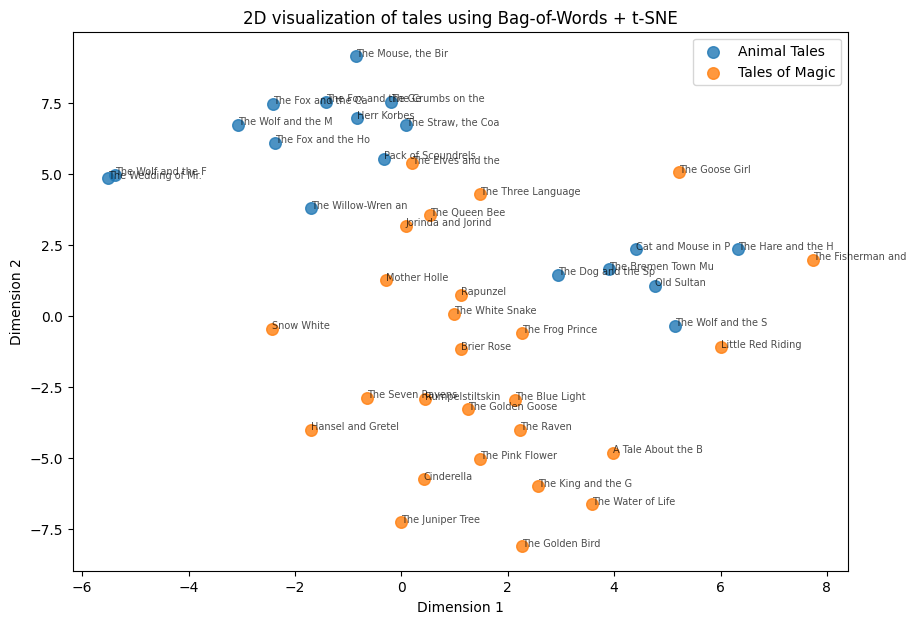

In [16]:
# 2D visualization of the tales using Bag-of-Words + Ward clusters.
# TruncatedSVD reduces sparse Bag-of-Words to a smaller numeric representation.
# t-SNE then maps the tales to 2D for visualization.

svd_components_bow = min(10, X_bow_cluster.shape[1] - 1, X_bow_cluster.shape[0] - 1)

X_bow_svd = TruncatedSVD(
    n_components=svd_components_bow,
    random_state=RANDOM_STATE
).fit_transform(X_bow_cluster)

perplexity_bow = min(10, max(2, (len(df) - 1) // 3))

X_bow_2d = TSNE(
    n_components=2,
    perplexity=perplexity_bow,
    init="random",
    learning_rate="auto",
    random_state=RANDOM_STATE
).fit_transform(X_bow_svd)

plot_bow_df = pd.DataFrame({
    "x": X_bow_2d[:, 0],
    "y": X_bow_2d[:, 1],
    "ATU Topic": df["ATU Topic"].values,
    "cluster_bow_ward": df["cluster_bow_ward"].values,
    "Title": df["Title"].values
})

plt.figure(figsize=(10, 7))

for topic, group in plot_bow_df.groupby("ATU Topic"):
    plt.scatter(
        group["x"],
        group["y"],
        label=topic,
        s=70,
        alpha=0.8
    )

for _, row in plot_bow_df.iterrows():
    plt.text(
        row["x"],
        row["y"],
        row["Title"][:18],
        fontsize=7,
        alpha=0.7
    )

plt.title("2D visualization of tales using Bag-of-Words + t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

In [17]:
df[df["cluster_bow_ward"] == 0]

,ATU Topic,Title,Abstract,Content,ATU Numerical,ATU Type,raw_text,processed_text,cluster,cluster_bow_ward
0,Tales of Magic,A Tale About the Boy Who Went Forth to Learn What Fear Was,A simple boy who just wants to be frightened.,"A certain father had two sons, the elder of who was smart and sensible, and could do everything, but the younger was stupid and could neither learn nor unde...",326.0,Supernatural Adversaries,"A Tale About the Boy Who Went Forth to Learn What Fear Was. A simple boy who just wants to be frightened.. A certain father had two sons, the elder of who w...",tale boy went forth learn fear simple boy just wants frightened certain father sons elder smart sensible younger stupid learn understand people saw said fel...,0,0
3,Tales of Magic,Cinderella,"The familiar story of a girl marrying a prince, despite her evil step-sisters doing their best to keep her down. This original version is a bit more bloody ...","The wife of a rich man fell sick; and when she felt that her end drew nigh, she called her only daughter to her bed-side, and said, ‘Always be a good girl, ...",510A,Supernatural Helpers,"Cinderella. The familiar story of a girl marrying a prince, despite her evil step-sisters doing their best to keep her down. This original version is a bit ...",cinderella familiar story girl marrying prince despite evil step sisters doing best original version bit bloody know wife rich man fell sick felt end drew n...,0,0
4,Tales of Magic,Hansel and Gretel,"A poor woodcutter can afford to feed his children, so he abandons them in the forest. They find an edible house, but the witch who lives inside ensnares the...",Hard by a great forest dwelt a poor wood-cutter with his wife and his two children. The boy was called Hansel and the girl Gretel. He had little to bite and...,327A,Supernatural Adversaries,"Hansel and Gretel. A poor woodcutter can afford to feed his children, so he abandons them in the forest. They find an edible house, but the witch who lives ...",hansel gretel poor woodcutter afford feed children abandons forest edible house witch lives inside ensnares want cook escape live happily hard great forest ...,0,0
19,Tales of Magic,The Fisherman and His Wife,"A fisherman catches a wish-granting flounder, and his wife wishes for more and more outlandish things.","There was once a fisherman who lived with his wife in a pigsty, close by the seaside. The fisherman used to go out all day long a-fishing; and one day, as h...",555.0,Supernatural Helpers,"The Fisherman and His Wife. A fisherman catches a wish-granting flounder, and his wife wishes for more and more outlandish things.. There was once a fisherm...",fisherman wife fisherman catches wish granting flounder wife wishes outlandish things fisherman lived wife pigsty close seaside fisherman used day long fish...,0,0
24,Tales of Magic,The Golden Bird,"A young prince manages to, despite ignoring almost all of the consistently correct advice given by a talking fox, obtain a golden bird, a golden horse, a be...","A certain king had a beautiful garden, and in the garden stood a tree which bore golden apples. These apples were always counted, and about the time when th...",550.0,Supernatural Helpers,"The Golden Bird. A young prince manages to, despite ignoring almost all of the consistently correct advice given by a talking fox, obtain a golden bird, a g...",golden bird young prince manages despite ignoring consistently correct advice given talking fox obtain golden bird golden horse beautiful princess kingdom c...,0,0
26,Tales of Magic,The Goose Girl,"A meek princess is usurped by her servant and is forced to tend to the geese in silence. A talking horse witnesses the events and, despite being killed, hel...","The king of a great land died, and left his queen to take care of their only child. This child was a daughter, who was very beautiful; and her mother loved ...",533.0,Supernatural Helpers,"The Goose Girl. A meek princess is usurped by her servant and is forced to 

# Part 2 — Supervised learning

Here we use `ATU Topic` as the target label.

## Train-test split decision

The dataset is small and the classes are not perfectly balanced, so the notebook uses a **70/30 stratified train-test split**:

- **70% training data**: used to fit the model.
- **30% test data**: held out for final evaluation.
- **Stratification**: keeps approximately the same proportion of `Animal Tales` and `Tales of Magic` in both train and test sets.

The supervised models use **TF-IDF** features instead of raw counts. TF-IDF reduces the weight of words that appear everywhere and gives more weight to words that are distinctive for particular tales or classes.


In [18]:
# proportion of tales in dataset
df["ATU Topic"].value_counts()

ATU Topic
Tales of Magic    26
Animal Tales      18
Name: count, dtype: int64

In [19]:
X = df["processed_text"]
y = df["ATU Topic"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("\nTraining distribution:")
display(y_train.value_counts(normalize=True).to_frame("proportion"))
print("\nTest distribution:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))


Train size: 30
Test size: 14

Training distribution:


,proportion
ATU Topic,
Tales of Magic,0.6
Animal Tales,0.4



Test distribution:


,proportion
ATU Topic,
Tales of Magic,0.571429
Animal Tales,0.428571


In [20]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=1)),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "pipeline": pipeline,
        "predictions": y_pred,
        "report": classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    }

summary = pd.DataFrame({
    name: {
        "accuracy": res["report"]["accuracy"],
        "macro_f1": res["report"]["macro avg"]["f1-score"],
        "weighted_f1": res["report"]["weighted avg"]["f1-score"]
    }
    for name, res in results.items()
}).T.sort_values("macro_f1", ascending=False)

display(summary)


,accuracy,macro_f1,weighted_f1
Random Forest,0.785714,0.784615,0.786813
Logistic Regression,0.642857,0.590643,0.611529
Decision Tree,0.571429,0.533333,0.552381


Decision Tree
                precision    recall  f1-score   support

  Animal Tales       0.50      0.33      0.40         6
Tales of Magic       0.60      0.75      0.67         8

      accuracy                           0.57        14
     macro avg       0.55      0.54      0.53        14
  weighted avg       0.56      0.57      0.55        14



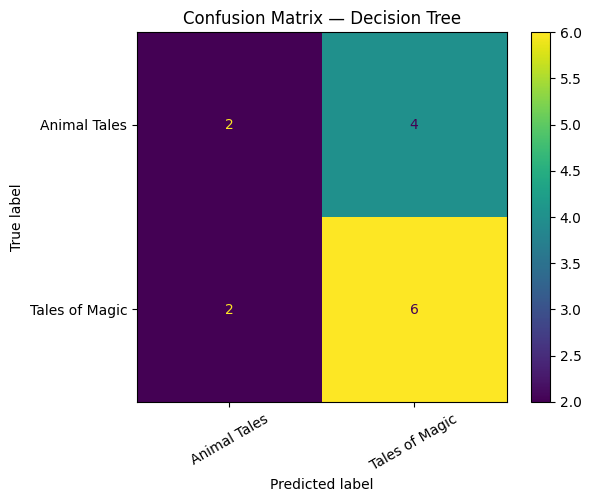

Random Forest
                precision    recall  f1-score   support

  Animal Tales       0.71      0.83      0.77         6
Tales of Magic       0.86      0.75      0.80         8

      accuracy                           0.79        14
     macro avg       0.79      0.79      0.78        14
  weighted avg       0.80      0.79      0.79        14



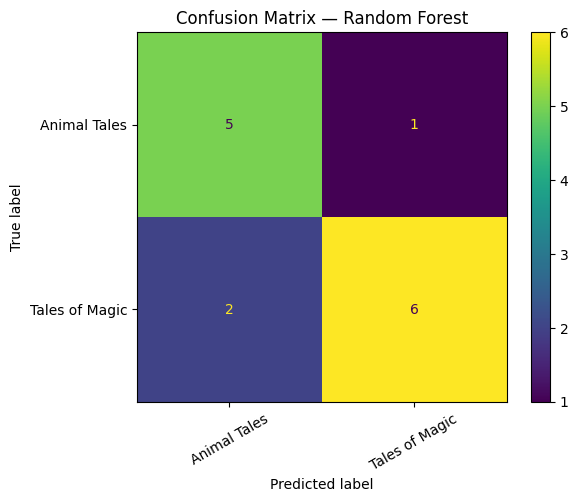

Logistic Regression
                precision    recall  f1-score   support

  Animal Tales       0.67      0.33      0.44         6
Tales of Magic       0.64      0.88      0.74         8

      accuracy                           0.64        14
     macro avg       0.65      0.60      0.59        14
  weighted avg       0.65      0.64      0.61        14



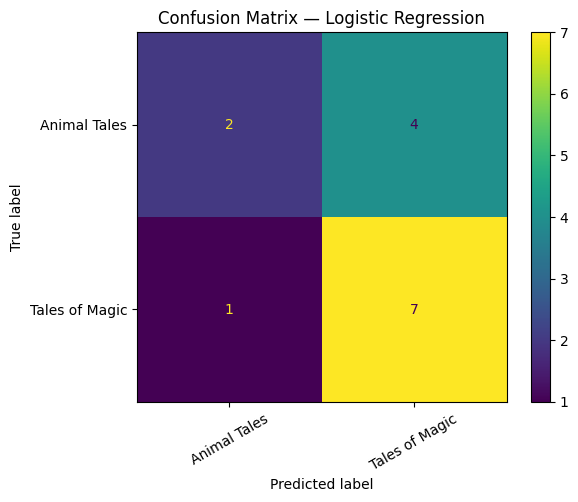

In [21]:
# Detailed reports and confusion matrices.
labels = sorted(y.unique())

for name, res in results.items():
    print("=" * 80)
    print(name)
    print(classification_report(y_test, res["predictions"], zero_division=0))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        res["predictions"],
        labels=labels,
        xticks_rotation=30
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


In [22]:
# Inspect the best model's predictions.
best_model_name = summary.index[0]
best_pipeline = results[best_model_name]["pipeline"]
best_predictions = results[best_model_name]["predictions"]

prediction_table = pd.DataFrame({
    "Title": df.loc[X_test.index, "Title"],
    "True ATU Topic": y_test,
    "Predicted ATU Topic": best_predictions
}).reset_index(drop=True)

print("Best model:", best_model_name)
display(prediction_table)


Best model: Random Forest


,Title,True ATU Topic,Predicted ATU Topic
0,The Willow-Wren and the Bear,Animal Tales,Animal Tales
1,The Fox and the Cat,Animal Tales,Animal Tales
2,The Elves and the Shoemaker,Tales of Magic,Animal Tales
3,The Bremen Town Musicians,Animal Tales,Tales of Magic
4,The Water of Life,Tales of Magic,Tales of Magic
5,A Tale About the Boy Who Went Forth to Learn What Fear Was,Tales of Magic,Tales of Magic
6,The Seven Ravens,Tales of Magic,Tales of Magic
7,The Dog and the Sparrow,Animal Tales,Animal Tales
8,The Hare and the Hedgehog,Animal Tales,Animal Tales
9,Brier Rose,Tales of Magic,Tales of Magic


In [23]:
# Feature interpretation for Logistic Regression.
# This helps explain which words/phrases are associated with each ATU Topic.
# Only available for the Logistic Regression pipeline.

lr_pipeline = results["Logistic Regression"]["pipeline"]
tfidf = lr_pipeline.named_steps["tfidf"]
lr_model = lr_pipeline.named_steps["model"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = lr_model.classes_

coef = lr_model.coef_
if coef.shape[0] == 1:
    # Binary case: positive coefficients push toward classes[1], negative toward classes[0].
    top_positive = np.argsort(coef[0])[-15:][::-1]
    top_negative = np.argsort(coef[0])[:15]

    print(f"Words/phrases pushing toward: {classes[1]}")
    display(pd.DataFrame({"term": feature_names[top_positive], "weight": coef[0][top_positive]}))

    print(f"Words/phrases pushing toward: {classes[0]}")
    display(pd.DataFrame({"term": feature_names[top_negative], "weight": coef[0][top_negative]}))
else:
    for class_idx, class_name in enumerate(classes):
        top_terms = np.argsort(coef[class_idx])[-15:][::-1]
        print(f"Words/phrases associated with: {class_name}")
        display(pd.DataFrame({"term": feature_names[top_terms], "weight": coef[class_idx][top_terms]}))

Words/phrases pushing toward: Tales of Magic


,term,weight
0,king,0.528349
1,son,0.278250
2,princess,0.277836
3,castle,0.268400
4,father,0.232683
5,golden,0.207062
6,rapunzel,0.199918
7,hansel,0.197882
8,dummling,0.182175
9,beautiful,0.181631


Words/phrases pushing toward: Animal Tales


,term,weight
0,wolf,-0.882027
1,fox,-0.808527
2,rooster,-0.566793
3,mouse,-0.434554
4,cat,-0.426136
5,sausage,-0.321765
6,sultan,-0.273776
7,lion,-0.231521
8,hen,-0.226895
9,mistress,-0.219832


## Conclusions and cautions

- The notebook predicts **`ATU Topic`** from tale text.
- The unsupervised section is useful for exploration: it shows whether tales naturally group by vocabulary and motifs.
- The supervised section is the actual prediction workflow.
- Because the dataset is small, test scores can vary a lot depending on the split. The stratified 70/30 split makes the evaluation fairer, but more tales would give a more reliable estimate.
- `ATU Numerical` and `ATU Type` were not used as model features because they are part of the ATU classification system and could make the task unrealistically easy through label leakage.
